In [1]:
import dr_datacube
import numpy as np
import polars as pl

from matplotlib import pyplot as plt

In [2]:
df = pl.read_parquet("/Users/corbettb/Documents/GitHub/dynamic_routing_facemap/results/decoding_results.parquet")

In [16]:
df.head()

session_id,n_trials,n_behavior_trials,n_lick_trials,n_no_lick_trials,lick_fraction,window_capture_start_s,window_capture_end_s,sampling_rate_hz,features_used,window_length_samples,cv_folds,status,error_type,error_message,behavior_n_blocks,behavior_hit_rate_mean,behavior_false_alarm_rate_mean,behavior_cross_modality_dprime_mean,behavior_aud_dprime_mean,behavior_vis_dprime_mean,behavior_n_contingent_rewards_mean,behavior_n_contingent_rewards_sum,behavior_n_good_blocks,behavior_n_engaged_blocks,cv_scores,window_start_s,window_end_s,window_center_s,cv_score_mean,cv_score_max,best_window_center_s
str,i64,i64,i64,i64,f64,f64,f64,f64,i64,i64,i64,str,null,null,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,list[f64],list[f64],list[f64],list[f64],f64,f64,f64
"""626791_2022-08-15""",479,449,211,238,0.469933,-0.25,0.5,60.0,200,1,5,"""success""",null,null,6,0.983333,0.350085,1.705494,0.653355,0.763818,16.666667,100.0,5,6,"[0.545468, 0.496779, … 0.803895]","[-0.25, -0.233333, … 0.483333]","[-0.233333, -0.216667, … 0.5]","[-0.241667, -0.225, … 0.491667]",0.627258,0.803895,0.491667
"""644864_2023-01-30""",535,505,248,257,0.491089,-0.25,0.5,60.0,200,1,5,"""success""",null,null,6,1.0,0.394068,1.827727,0.600585,0.669726,19.0,114.0,6,6,"[0.49901, 0.532673, … 0.774257]","[-0.25, -0.233333, … 0.483333]","[-0.233333, -0.216667, … 0.5]","[-0.241667, -0.225, … 0.491667]",0.624862,0.821782,0.358333
"""644864_2023-01-31""",515,485,239,246,0.492784,-0.25,0.5,60.0,200,1,5,"""success""",null,null,6,0.993056,0.403585,1.670656,0.633748,0.645287,17.833333,107.0,6,6,"[0.482474, 0.519588, … 0.723711]","[-0.25, -0.233333, … 0.483333]","[-0.233333, -0.216667, … 0.5]","[-0.241667, -0.225, … 0.491667]",0.595052,0.748454,0.458333
"""644864_2023-02-02""",513,483,182,301,0.376812,-0.25,0.5,60.0,200,1,5,"""success""",null,null,6,0.991228,0.232621,2.424336,1.096701,0.993639,17.333333,104.0,6,6,"[0.544287, 0.511469, … 0.737049]","[-0.25, -0.233333, … 0.483333]","[-0.233333, -0.216667, … 0.5]","[-0.241667, -0.225, … 0.491667]",0.652445,0.780498,0.341667
"""644866_2023-02-07""",467,437,233,204,0.533181,-0.25,0.5,60.0,200,1,5,"""success""",null,null,6,0.975,0.480426,1.376887,-0.527538,1.040588,16.666667,100.0,4,6,"[0.512382, 0.507941, … 0.764211]","[-0.25, -0.233333, … 0.483333]","[-0.233333, -0.216667, … 0.5]","[-0.241667, -0.225, … 0.491667]",0.635704,0.848746,0.408333


In [18]:
df['window_center_s'][0] - df['window_start_s'][0]

""
f64
0.008333
0.008333
0.008333
0.008333
0.008333
…
0.008333
0.008333
0.008333


Text(0, 0.5, 'CV Score: lick vs no lick trials')

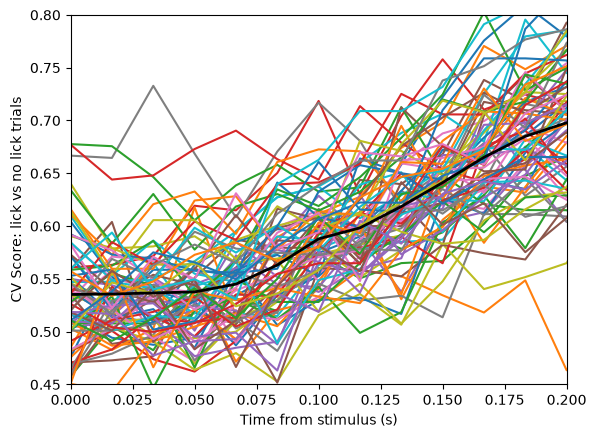

In [20]:
window_centers  = np.array(df['window_center_s'][0]) + 1/120 #add in a half frame to account for motSVD diff

scores = np.stack(df['cv_scores'].to_numpy())

plt.plot(window_centers, scores.T)
plt.plot(window_centers, scores.mean(axis=0), color='k', linewidth=2)

plt.xlim(0, 0.2)
plt.ylim(0.45, 0.8)
plt.xlabel('Time from stimulus (s)')
plt.ylabel('CV Score: lick vs no lick trials')

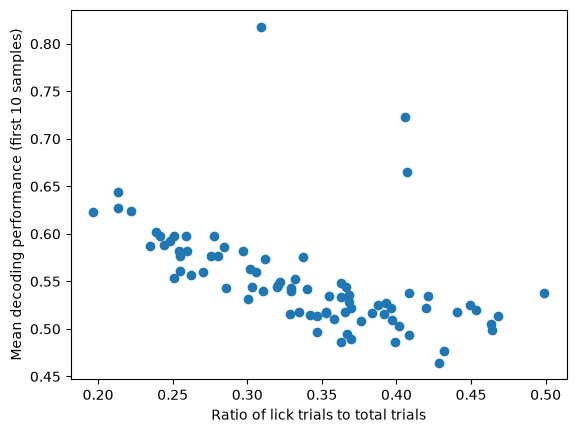

In [24]:
# plot the ratio of lick trials to total trials against the decoding performance in first 10 samples
ratio = df["n_lick_trials"] / df["n_trials"]
performance_first_10 = df.with_columns(
    pl.col("cv_scores").list.slice(0, 10).alias("performance_first_10")
).select("performance_first_10")

mean_performance_first_10 = performance_first_10.select(
    pl.col("performance_first_10").list.mean()
).to_series()

plt.scatter(ratio, mean_performance_first_10)
plt.xlabel("Ratio of lick trials to total trials")
plt.ylabel("Mean decoding performance (first 10 samples)")
plt.show()